# E-Commerce Cohort Analysis

**Stack:** Python · Pandas · SQLite · Matplotlib  
**Dataset:** 1,000 orders · 200 customers · Jan–Dec 2024

### Objectives
1. Build a 3-layer data pipeline: raw → cleaned → analytics
2. Calculate retention rates by cohort (1, 2, 3 months)
3. Measure repeat purchase rates (2nd, 3rd, 4th order)
4. Visualize cohort size evolution over time


## 1. Setup & Data Ingestion

In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#0d1117',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'axes.titlecolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.8,
    'text.color':       '#e6edf3',
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.labelsize':   11,
})

print('Libraries loaded ✓')

Libraries loaded ✓


In [ ]:
# ── Layer 1: Raw data ──
raw_df = pd.read_csv('ecom_orders.csv')
raw_df['order_date'] = pd.to_datetime(raw_df['order_date'])

print('=== RAW DATA OVERVIEW ===')
print(f'Total orders     : {len(raw_df):,}')
print(f'Unique customers : {raw_df["customer_id"].nunique():,}')
print(f'Date range       : {raw_df["order_date"].min().date()} → {raw_df["order_date"].max().date()}')
print(f'Avg order value  : ${raw_df["sales"].mean():.2f}')
print(f'Total revenue    : ${raw_df["sales"].sum():,.2f}')
print()
print('Sample:')
raw_df.head()

=== RAW DATA OVERVIEW ===
Total orders     : 1,000
Unique customers : 200
Date range       : 2024-01-01 → 2024-12-31
Avg order value  : $156.79
Total revenue    : $156,794.76

Sample:


,row_id,customer_id,order_date,order_id,sales
0,1,CUST001,2024-06-02,ORD1000,76.93
1,2,CUST001,2024-07-26,ORD1001,251.35
2,3,CUST001,2024-10-12,ORD1002,135.91
3,4,CUST002,2024-04-11,ORD1003,217.41
4,5,CUST002,2024-05-24,ORD1004,291.87


## 2. Data Pipeline (3 Layers)

In [ ]:
# ── Layer 2: Cleaned & validated data ──
cleaned_df = (
    raw_df
    .dropna(subset=['customer_id', 'order_date'])
    .query('sales > 0')
    .assign(
        order_date   = lambda x: x['order_date'].dt.normalize(),
        sales_amount = lambda x: x['sales'].round(2),
        processed_at = pd.Timestamp.now()
    )
    [['customer_id', 'order_date', 'order_id', 'sales_amount', 'processed_at']]
    .reset_index(drop=True)
)

# ── Load into SQLite (in-memory warehouse) ──
con = sqlite3.connect(':memory:')
raw_df.to_sql('ecom_orders_raw', con, index=False, if_exists='replace')
cleaned_df.to_sql('cleaned_orders', con, index=False, if_exists='replace')

print('=== PIPELINE LAYER COUNTS ===')
for layer, tbl in [('raw', 'ecom_orders_raw'), ('cleaned', 'cleaned_orders')]:
    n = pd.read_sql(f'SELECT COUNT(*) AS n FROM {tbl}', con)['n'][0]
    print(f'  {layer:<10}: {n:,} records')

print(f'\nRows removed in cleaning: {len(raw_df) - len(cleaned_df)}')
print('Cleaned sample:')
cleaned_df.head()

=== PIPELINE LAYER COUNTS ===
  raw       : 1,000 records
  cleaned   : 1,000 records

Rows removed in cleaning: 0
Cleaned sample:


,customer_id,order_date,order_id,sales_amount,processed_at
0,CUST001,2024-06-02,ORD1000,76.93,2026-04-23 17:55:50.697919
1,CUST001,2024-07-26,ORD1001,251.35,2026-04-23 17:55:50.697919
2,CUST001,2024-10-12,ORD1002,135.91,2026-04-23 17:55:50.697919
3,CUST002,2024-04-11,ORD1003,217.41,2026-04-23 17:55:50.697919
4,CUST002,2024-05-24,ORD1004,291.87,2026-04-23 17:55:50.697919


In [ ]:
# ── Layer 3: Analytics — cohort_analysis table ──
cohort_analysis = pd.read_sql('''
WITH first_order AS (
    SELECT customer_id, MIN(order_date) AS first_order_date
    FROM cleaned_orders
    GROUP BY customer_id
),
second_order AS (
    SELECT o.customer_id, MIN(o.order_date) AS second_order_date
    FROM cleaned_orders o
    INNER JOIN first_order f ON o.customer_id = f.customer_id
    WHERE o.order_date > f.first_order_date
    GROUP BY o.customer_id
)
SELECT
    f.customer_id,
    f.first_order_date,
    s.second_order_date,
    CAST(JULIANDAY(s.second_order_date) - JULIANDAY(f.first_order_date) AS INTEGER)
        AS days_until_second_order,
    CASE WHEN s.second_order_date IS NULL THEN "did not return" ELSE "returned" END
        AS returned
FROM first_order f
LEFT JOIN second_order s ON f.customer_id = s.customer_id
''', con)

cohort_analysis.to_sql('cohort_analysis', con, index=False, if_exists='replace')

returned_pct = (cohort_analysis['returned'] == 'returned').mean() * 100
print(f'Customers who made a 2nd purchase: {returned_pct:.1f}%')
print(f'Avg days until 2nd order: {cohort_analysis["days_until_second_order"].mean():.0f} days')
cohort_analysis.head()

Customers who made a 2nd purchase: 99.0%
Avg days until 2nd order: 50 days


,customer_id,first_order_date,second_order_date,days_until_second_order,returned
0,CUST001,2024-04-12 00:00:00,2024-06-02 00:00:00,51.0,returned
1,CUST002,2024-04-11 00:00:00,2024-05-24 00:00:00,43.0,returned
2,CUST003,2024-01-14 00:00:00,2024-05-28 00:00:00,135.0,returned
3,CUST004,2024-01-31 00:00:00,2024-02-24 00:00:00,24.0,returned
4,CUST005,2024-03-16 00:00:00,2024-03-25 00:00:00,9.0,returned


## 3. Analytics Queries

In [ ]:
# ── Query 1: Retention rate by cohort ──
retention = pd.read_sql('''
WITH first_purchase AS (
    SELECT customer_id, MIN(order_date) AS first_purchase_date
    FROM cleaned_orders GROUP BY customer_id
),
with_second AS (
    SELECT
        f.customer_id,
        f.first_purchase_date,
        MIN(CASE WHEN o.order_date > f.first_purchase_date THEN o.order_date END)
            AS second_purchase_date
    FROM first_purchase f
    LEFT JOIN cleaned_orders o ON f.customer_id = o.customer_id
    GROUP BY f.customer_id, f.first_purchase_date
)
SELECT
    STRFTIME("%Y-%m", first_purchase_date)  AS cohort_month,
    COUNT(*)                                 AS total_customers,
    ROUND(SUM(CASE WHEN second_purchase_date IS NOT NULL
        AND JULIANDAY(second_purchase_date) - JULIANDAY(first_purchase_date) <= 30
        THEN 1.0 ELSE 0 END) * 100 / COUNT(*), 2) AS retention_1m,
    ROUND(SUM(CASE WHEN second_purchase_date IS NOT NULL
        AND JULIANDAY(second_purchase_date) - JULIANDAY(first_purchase_date) <= 60
        THEN 1.0 ELSE 0 END) * 100 / COUNT(*), 2) AS retention_2m,
    ROUND(SUM(CASE WHEN second_purchase_date IS NOT NULL
        AND JULIANDAY(second_purchase_date) - JULIANDAY(first_purchase_date) <= 90
        THEN 1.0 ELSE 0 END) * 100 / COUNT(*), 2) AS retention_3m
FROM with_second
GROUP BY cohort_month
ORDER BY cohort_month
''', con)

print('Retention Rate by Cohort:')
retention

Retention Rate by Cohort:


,cohort_month,total_customers,retention_1m,retention_2m,retention_3m
0,2024-01,66,37.88,60.61,77.27
1,2024-02,48,35.42,66.67,79.17
2,2024-03,33,30.30,72.73,87.88
3,2024-04,27,51.85,88.89,92.59
4,2024-05,16,50.00,93.75,100.00
5,2024-06,10,30.00,100.00,100.00


In [ ]:
# ── Query 2: Repeat purchase rate ──
repeat_rate = pd.read_sql('''
WITH order_counts AS (
    SELECT customer_id, MIN(order_date) AS first_order_date, COUNT(*) AS total_orders
    FROM cleaned_orders
    GROUP BY customer_id
)
SELECT
    STRFTIME("%Y-%m", first_order_date) AS cohort_month,
    COUNT(*)                             AS total_customers,
    ROUND(SUM(CASE WHEN total_orders >= 2 THEN 1.0 ELSE 0 END) * 100 / COUNT(*), 2)
        AS rate_2nd_order,
    ROUND(SUM(CASE WHEN total_orders >= 3 THEN 1.0 ELSE 0 END) * 100 / COUNT(*), 2)
        AS rate_3rd_order,
    ROUND(SUM(CASE WHEN total_orders >= 4 THEN 1.0 ELSE 0 END) * 100 / COUNT(*), 2)
        AS rate_4th_order
FROM order_counts
GROUP BY cohort_month
ORDER BY cohort_month
''', con)

print('Repeat Purchase Rate by Cohort:')
repeat_rate

Repeat Purchase Rate by Cohort:


,cohort_month,total_customers,rate_2nd_order,rate_3rd_order,rate_4th_order
0,2024-01,66,100.00,98.48,83.33
1,2024-02,48,97.92,95.83,81.25
2,2024-03,33,100.00,93.94,81.82
3,2024-04,27,96.30,85.19,77.78
4,2024-05,16,100.00,93.75,68.75
5,2024-06,10,100.00,70.00,60.00


In [ ]:
# ── Query 3: Cohort size by month ──
cohort_size = pd.read_sql('''
WITH first_purchase AS (
    SELECT customer_id, MIN(order_date) AS first_purchase_date
    FROM cleaned_orders GROUP BY customer_id
)
SELECT
    STRFTIME("%Y-%m", first_purchase_date) AS cohort_month,
    COUNT(*) AS new_customers
FROM first_purchase
GROUP BY cohort_month
ORDER BY cohort_month
''', con)

print('Cohort Size by Month:')
cohort_size

Cohort Size by Month:


,cohort_month,new_customers
0,2024-01,66
1,2024-02,48
2,2024-03,33
3,2024-04,27
4,2024-05,16
5,2024-06,10


## 4. Visualizations

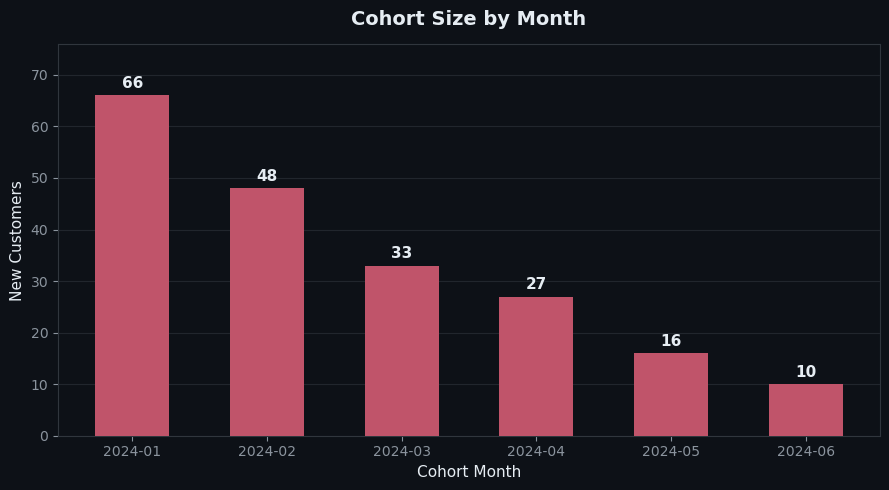

Saved: cohort_size.png


In [ ]:
# ── Chart 1: Cohort Size by Month ──
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0d1117')

bars = ax.bar(
    cohort_size['cohort_month'],
    cohort_size['new_customers'],
    color='#c0546a', width=0.55, zorder=3
)

# Value labels on bars
for bar, val in zip(bars, cohort_size['new_customers']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        str(val), ha='center', va='bottom',
        color='#e6edf3', fontsize=11, fontweight='bold'
    )

ax.set_title('Cohort Size by Month', fontweight='bold', pad=14)
ax.set_xlabel('Cohort Month')
ax.set_ylabel('New Customers')
ax.set_ylim(0, cohort_size['new_customers'].max() * 1.15)
ax.grid(axis='y', zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('cohort_size.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: cohort_size.png')

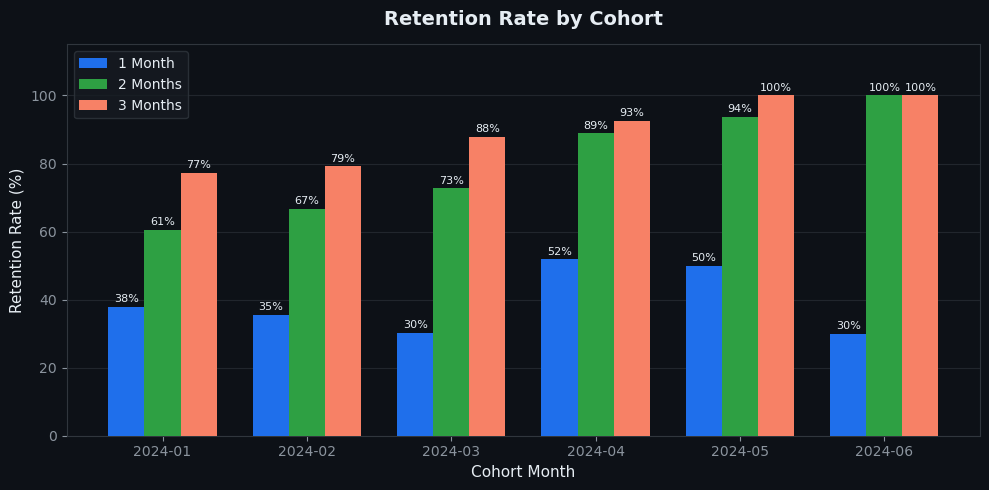

Saved: retention_rate.png


In [ ]:
# ── Chart 2: Retention Rate by Cohort (grouped bars) ──
# FIX: Use grouped bars instead of 100%-stacked — shows real rates, not just
# proportions. Each cohort month now has 3 bars for 1M / 2M / 3M retention.

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d1117')

months   = retention['cohort_month']
x        = np.arange(len(months))
w        = 0.25
colors   = ['#1f6feb', '#2ea043', '#f78166']
labels   = ['1 Month', '2 Months', '3 Months']
cols     = ['retention_1m', 'retention_2m', 'retention_3m']

for i, (col, label, color) in enumerate(zip(cols, labels, colors)):
    bars = ax.bar(x + i * w, retention[col], width=w, label=label, color=color, zorder=3)
    for bar, val in zip(bars, retention[col]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{val:.0f}%', ha='center', va='bottom',
            color='#e6edf3', fontsize=8
        )

ax.set_title('Retention Rate by Cohort', fontweight='bold', pad=14)
ax.set_xlabel('Cohort Month')
ax.set_ylabel('Retention Rate (%)')  # FIX: explicit unit on Y axis
ax.set_ylim(0, 115)                  # FIX: Y axis starts at 0
ax.set_xticks(x + w)
ax.set_xticklabels(months)
ax.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3')
ax.grid(axis='y', zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('retention_rate.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: retention_rate.png')

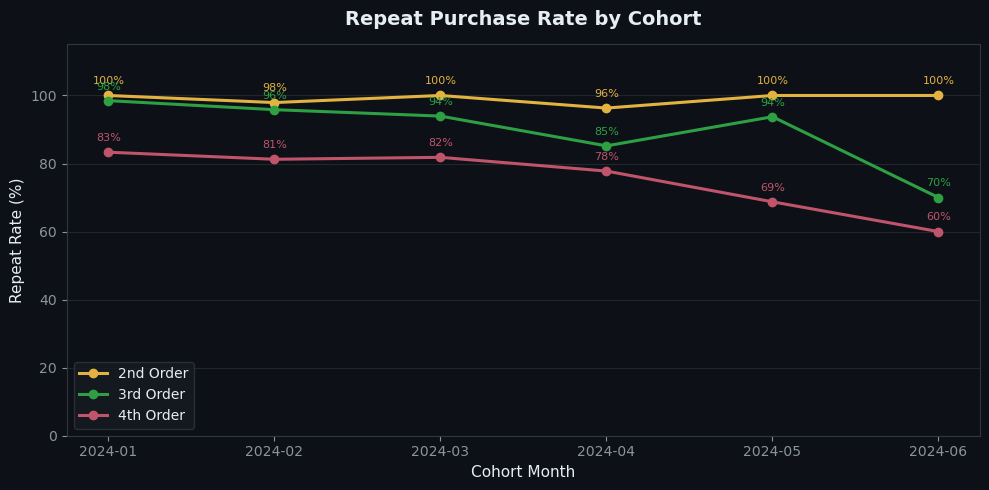

Saved: repeat_purchase_rate.png


In [ ]:
# ── Chart 3: Repeat Purchase Rate by Cohort ──
# FIX 1: Y axis now starts at 0 (was cut at ~60, exaggerating differences)
# FIX 2: Y axis label shows "Repeat Rate (%)" instead of just "Order"
# FIX 3: Data labels added on each point for clarity

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d1117')

months  = repeat_rate['cohort_month']
x       = np.arange(len(months))
palette = {'rate_2nd_order': ('#e3b341', '2nd Order'),
           'rate_3rd_order': ('#2ea043', '3rd Order'),
           'rate_4th_order': ('#c0546a', '4th Order')}

for col, (color, label) in palette.items():
    vals = repeat_rate[col]
    ax.plot(months, vals, color=color, linewidth=2.2, marker='o',
            markersize=6, label=label, zorder=3)
    for xi, vi in zip(months, vals):
        ax.annotate(f'{vi:.0f}%', (xi, vi),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=8, color=color)

ax.set_title('Repeat Purchase Rate by Cohort', fontweight='bold', pad=14)
ax.set_xlabel('Cohort Month')
ax.set_ylabel('Repeat Rate (%)')   # FIX: correct label
ax.set_ylim(0, 115)                # FIX: starts at 0
ax.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3')
ax.grid(axis='y', zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('repeat_purchase_rate.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: repeat_purchase_rate.png')

## 5. Key Insights

In [11]:
print('=' * 52)
print('         KEY INSIGHTS — E-Commerce Cohorts')
print('=' * 52)

avg_ret_3m = retention['retention_3m'].mean()
best_cohort = retention.loc[retention['retention_3m'].idxmax(), 'cohort_month']
avg_2nd = repeat_rate['rate_2nd_order'].mean()
avg_4th = repeat_rate['rate_4th_order'].mean()
largest = cohort_size.loc[cohort_size['new_customers'].idxmax()]

print(f'\n1. Average 3-month retention rate : {avg_ret_3m:.1f}%')
print(f'   Best performing cohort         : {best_cohort}')
print(f'\n2. Avg customers placing 2nd order: {avg_2nd:.1f}%')
print(f'   Avg customers placing 4th order: {avg_4th:.1f}%')
print(f'\n3. Largest cohort: {largest["cohort_month"]} ({largest["new_customers"]} customers)')
print(f'   Cohort size decreasing trend → data truncation or acquisition slowdown')
print(f'\n4. Repeat purchase rates are very high (>95% for 2nd order)')
print(f'   → Strong product-market fit once customer makes first purchase')
print(f'\n5. Main retention challenge is the 1-month window (~30–52%)')
print(f'   → Opportunity: re-engagement campaigns within first 30 days')
print('=' * 52)

         KEY INSIGHTS — E-Commerce Cohorts

1. Average 3-month retention rate : 89.5%
   Best performing cohort         : 2024-05

2. Avg customers placing 2nd order: 99.0%
   Avg customers placing 4th order: 75.5%

3. Largest cohort: 2024-01 (66 customers)
   Cohort size decreasing trend → data truncation or acquisition slowdown

4. Repeat purchase rates are very high (>95% for 2nd order)
   → Strong product-market fit once customer makes first purchase

5. Main retention challenge is the 1-month window (~30–52%)
   → Opportunity: re-engagement campaigns within first 30 days


## 6. Pipeline Validation

In [ ]:
# ── Record count check across all 3 layers ──
validation = pd.read_sql('''
SELECT "raw"      AS layer, COUNT(*) AS record_count FROM ecom_orders_raw
UNION ALL
SELECT "cleaned"  AS layer, COUNT(*) AS record_count FROM cleaned_orders
UNION ALL
SELECT "analytics" AS layer, COUNT(*) AS record_count FROM cohort_analysis
''', con)

print('Pipeline Validation — Record counts per layer:')
print(validation.to_string(index=False))

raw_count     = validation.loc[validation['layer'] == 'raw',      'record_count'].values[0]
cleaned_count = validation.loc[validation['layer'] == 'cleaned',  'record_count'].values[0]
analytics_count = validation.loc[validation['layer'] == 'analytics', 'record_count'].values[0]

print(f'\nRows dropped in cleaning  : {raw_count - cleaned_count}')
print(f'Analytics = unique customers: {analytics_count == cleaned_df["customer_id"].nunique()}')

assert cleaned_count <= raw_count, 'ERROR: cleaned has more rows than raw!'
assert analytics_count == cleaned_df['customer_id'].nunique(), 'ERROR: analytics row count mismatch!'
print('\nAll validation checks passed ✓')

Pipeline Validation — Record counts per layer:
    layer  record_count
      raw          1000
  cleaned          1000
analytics           200

Rows dropped in cleaning  : 0
Analytics = unique customers: True

All validation checks passed ✓
